# 03 — Exploratory Data Analysis (EDA)
**E-Commerce Customer Behavior Analysis and Segmentation**
Module: IT2011 – Artificial Intelligence and Machine Learning | Group ID: 2026-Y2-S1-KU-01

**EDA Lead:** Liyanage D.D.S (IT25100119)

This notebook uses:
- `1_cleaned_data_nayanajith.csv` — cleaned transaction-level data (Data Cleaning stage)
- `2_rfm_data_herath.csv` — customer-level RFM features (Feature Engineering stage)

Goals:
1. Visualize the Top 10 selling products
2. Visualize sales trends over time
3. Visualize the distribution of RFM scores
4. Save the final `customer_rfm_data.csv` for Sub-Team B (ML modeling)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 1. Load the cleaned data and the RFM feature data

In [2]:
clean_path = "../outputs/1_cleaned_data_nayanajith.csv"
rfm_path = "../outputs/2_rfm_data_herath.csv"

df = pd.read_csv(clean_path)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

rfm = pd.read_csv(rfm_path)

print("Cleaned transaction data:", df.shape)
print("RFM customer data:", rfm.shape)
df.head()


Cleaned transaction data: (374706, 9)
RFM customer data: (4265, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalCost
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
rfm.head()


,CustomerID,Recency,Frequency,Monetary,Log_R,Log_F,Log_M,Scaled_R,Scaled_F,Scaled_M
0,12346.0,165,11,372.86,5.111988,2.484907,5.923881,0.972513,1.637855,-0.411025
1,12347.0,3,2,1285.07,1.386294,1.098612,7.159346,-1.900332,-0.388476,0.540252
2,12348.0,74,1,222.16,4.317488,0.693147,5.407889,0.359882,-0.981140,-0.808326
3,12349.0,43,2,1676.69,3.784190,1.098612,7.425173,-0.051339,-0.388476,0.744932
4,12351.0,11,1,288.18,2.484907,0.693147,5.667049,-1.053203,-0.981140,-0.608779


## 2. Top 10 Selling Products
We look at the top products both by **quantity sold** and by **revenue generated**
(`TotalCost` = Quantity × Price), since the best sellers by volume are not always
the biggest revenue drivers.


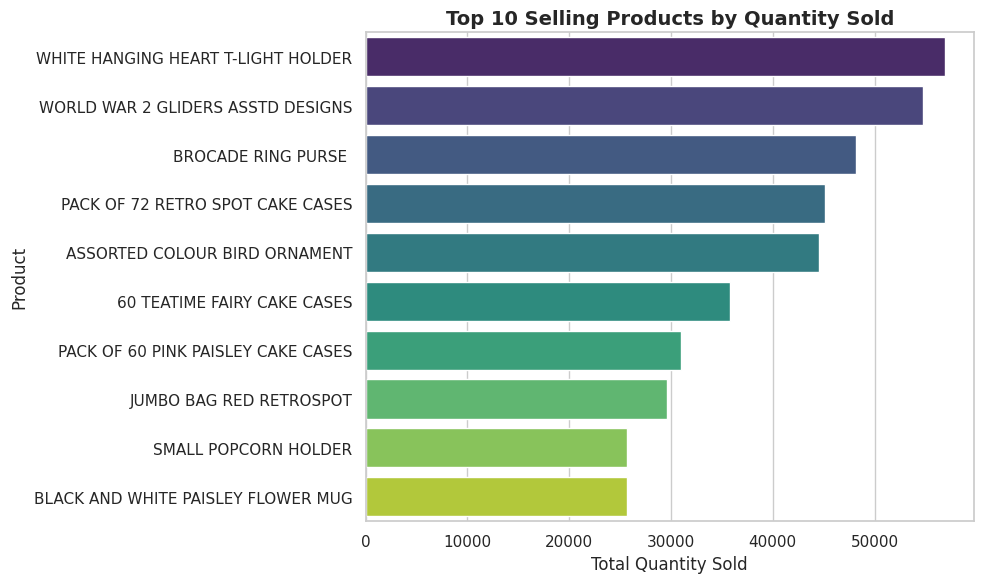

In [4]:
top10_qty = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_qty.values, y=top10_qty.index, hue=top10_qty.index,
            palette="viridis", legend=False)
plt.title("Top 10 Selling Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../outputs/figures/top10_products_quantity.png", dpi=150)
plt.show()


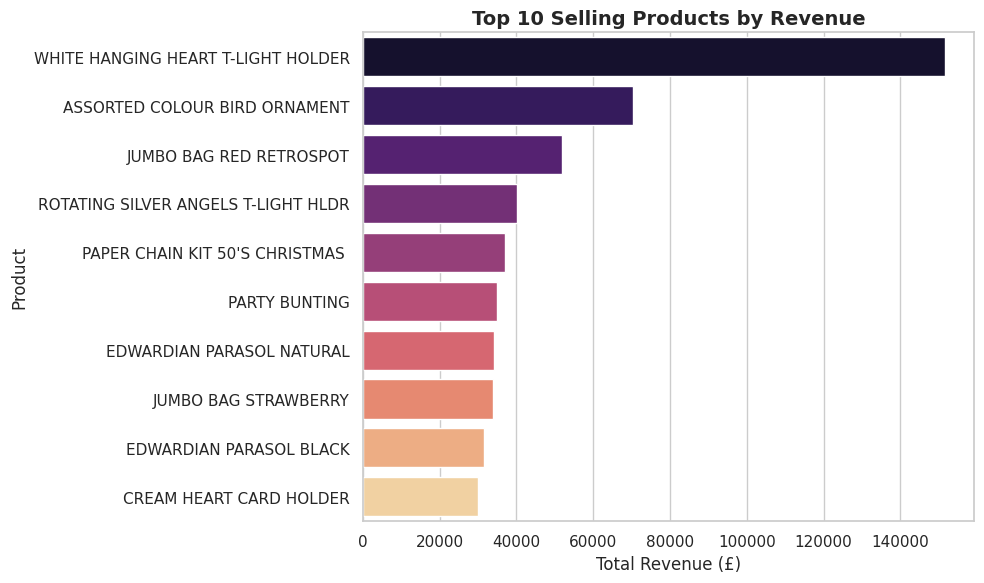

In [5]:
top10_rev = (
    df.groupby("Description")["TotalCost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_rev.values, y=top10_rev.index, hue=top10_rev.index,
            palette="magma", legend=False)
plt.title("Top 10 Selling Products by Revenue")
plt.xlabel("Total Revenue (\u00a3)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("../outputs/figures/top10_products_revenue.png", dpi=150)
plt.show()


## 3. Sales Trends Over Time
Monthly revenue and monthly order volume, aggregated from `InvoiceDate`.


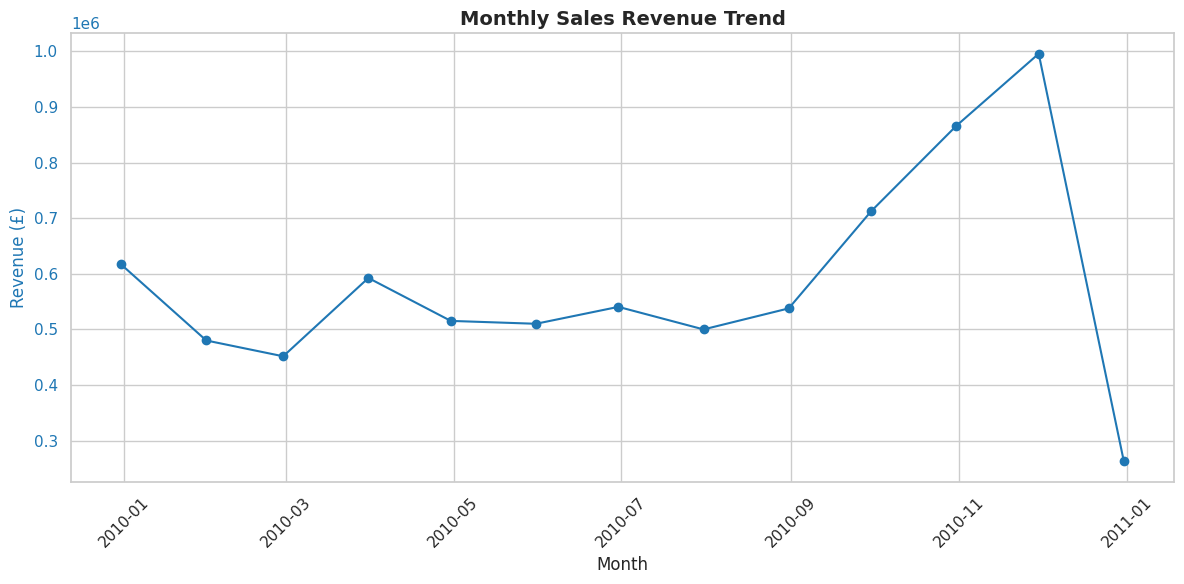

In [6]:
monthly = df.set_index("InvoiceDate").resample("ME").agg(
    Revenue=("TotalCost", "sum"),
    Orders=("Invoice", "nunique")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly["InvoiceDate"], monthly["Revenue"], color="tab:blue", marker="o")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (\u00a3)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Monthly Sales Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_revenue_trend.png", dpi=150)
plt.show()


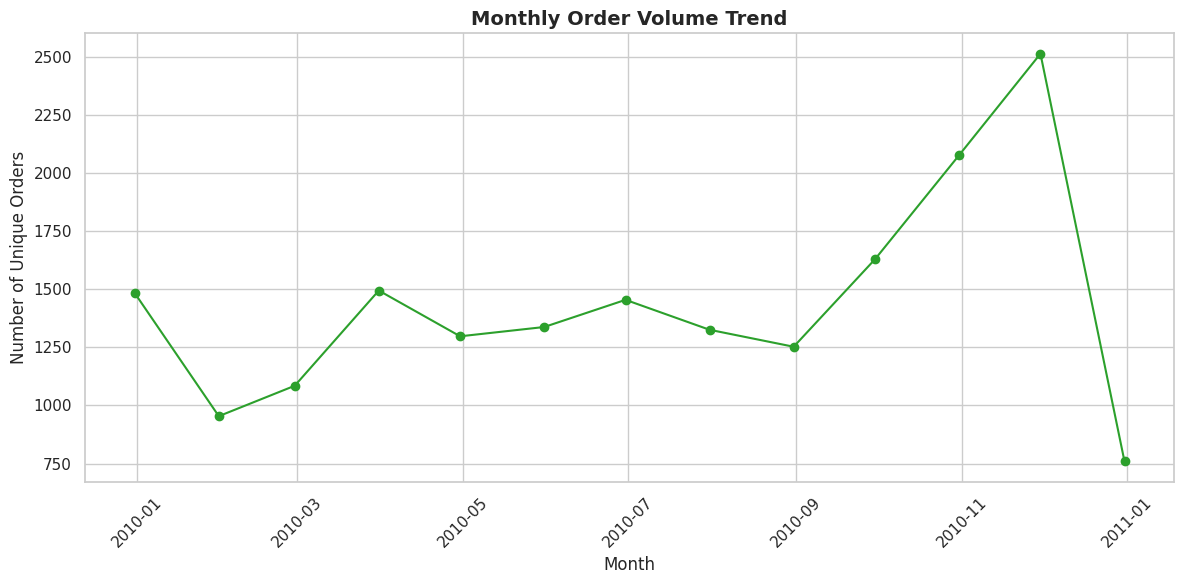

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(monthly["InvoiceDate"], monthly["Orders"], color="tab:green", marker="o")
plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Unique Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_orders_trend.png", dpi=150)
plt.show()


## 4. Sales by Country (context for segmentation)

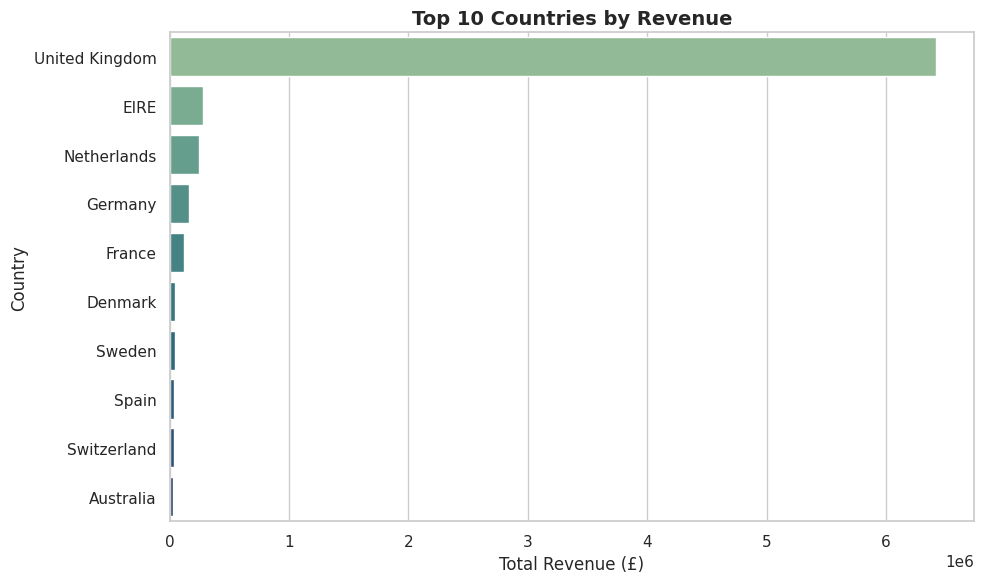

In [8]:
top_countries = (
    df.groupby("Country")["TotalCost"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="crest", legend=False)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue (\u00a3)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../outputs/figures/top10_countries_revenue.png", dpi=150)
plt.show()


## 5. Distribution of RFM Scores
Raw Recency, Frequency and Monetary values are heavily right-skewed (a small
number of customers buy very often / spend a lot). We look at both the raw
distributions and the log-transformed ones that Feature Engineering produced.


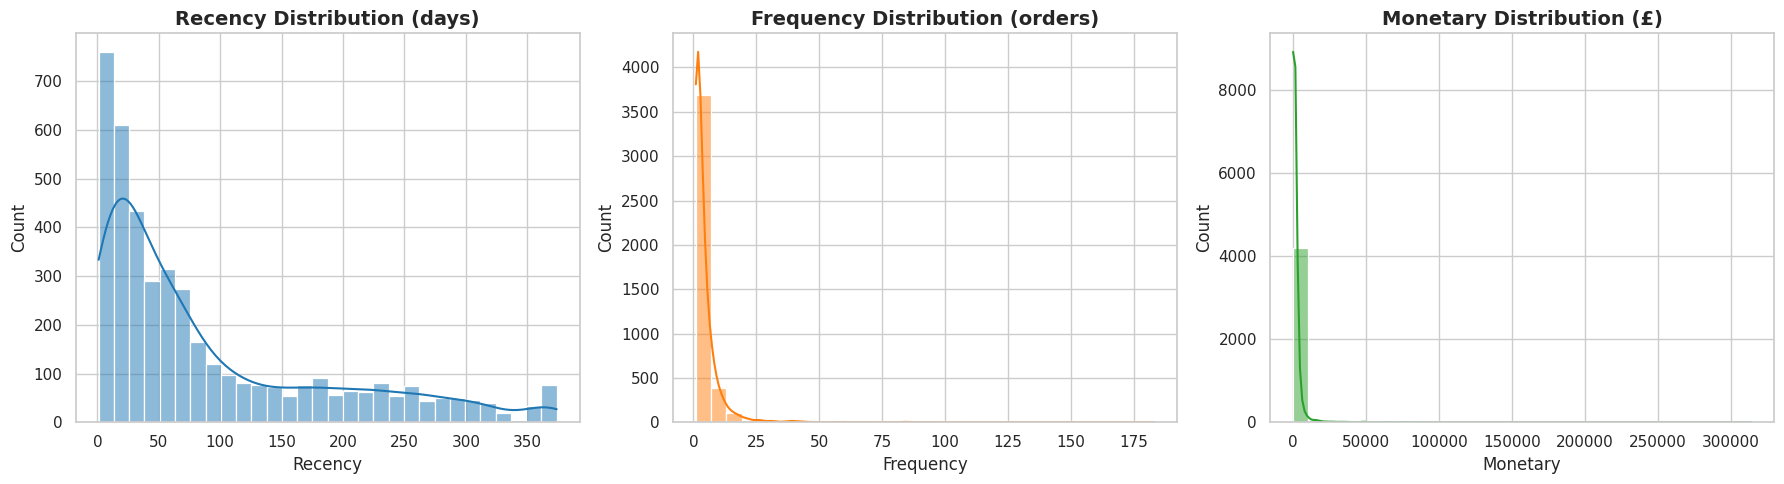

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, color="tab:blue", ax=axes[0])
axes[0].set_title("Recency Distribution (days)")

sns.histplot(rfm["Frequency"], bins=30, kde=True, color="tab:orange", ax=axes[1])
axes[1].set_title("Frequency Distribution (orders)")

sns.histplot(rfm["Monetary"], bins=30, kde=True, color="tab:green", ax=axes[2])
axes[2].set_title("Monetary Distribution (\u00a3)")

plt.tight_layout()
plt.savefig("../outputs/figures/rfm_raw_distributions.png", dpi=150)
plt.show()


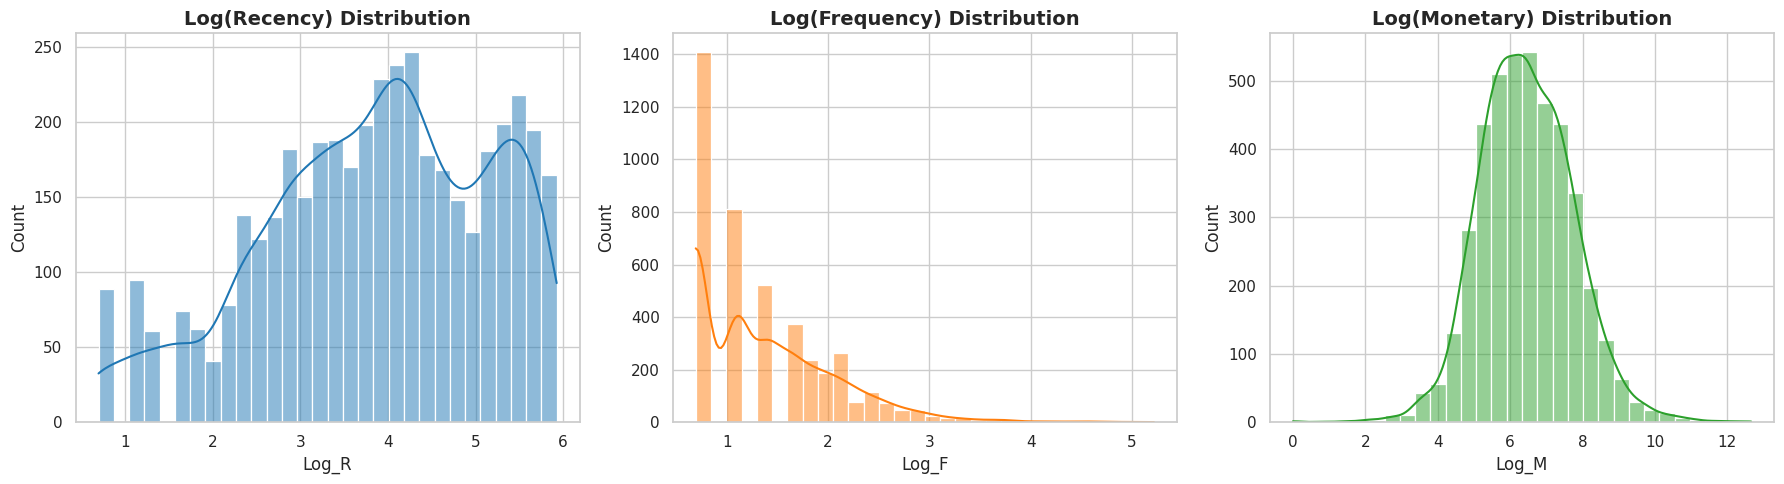

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Log_R"], bins=30, kde=True, color="tab:blue", ax=axes[0])
axes[0].set_title("Log(Recency) Distribution")

sns.histplot(rfm["Log_F"], bins=30, kde=True, color="tab:orange", ax=axes[1])
axes[1].set_title("Log(Frequency) Distribution")

sns.histplot(rfm["Log_M"], bins=30, kde=True, color="tab:green", ax=axes[2])
axes[2].set_title("Log(Monetary) Distribution")

plt.tight_layout()
plt.savefig("../outputs/figures/rfm_log_distributions.png", dpi=150)
plt.show()


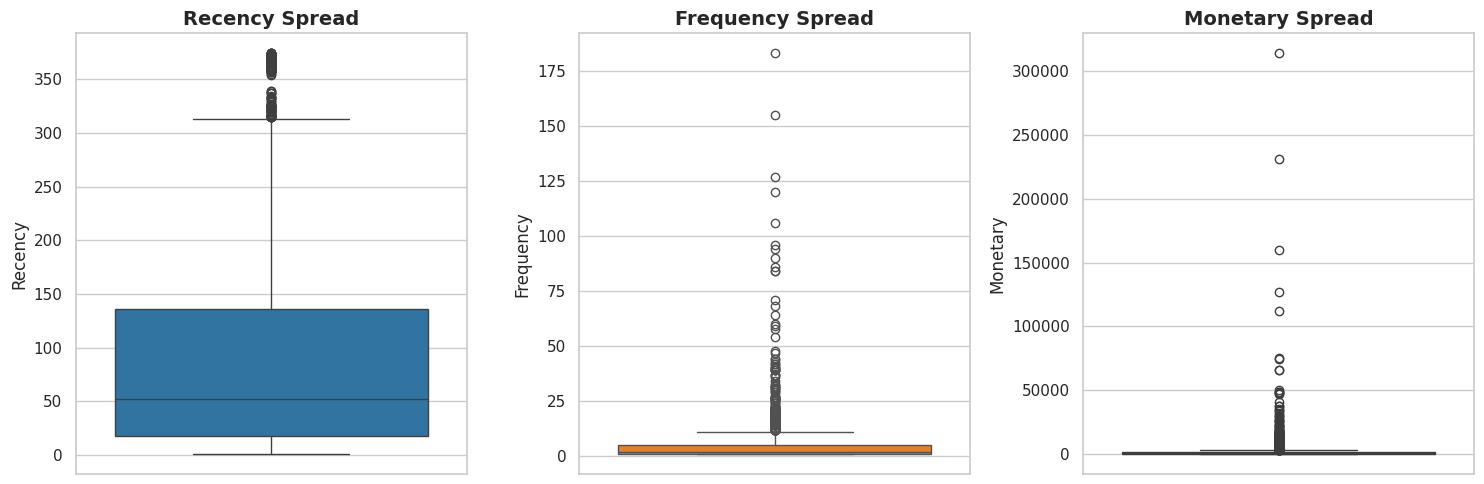

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=rfm["Recency"], color="tab:blue", ax=axes[0])
axes[0].set_title("Recency Spread")
sns.boxplot(y=rfm["Frequency"], color="tab:orange", ax=axes[1])
axes[1].set_title("Frequency Spread")
sns.boxplot(y=rfm["Monetary"], color="tab:green", ax=axes[2])
axes[2].set_title("Monetary Spread")
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_boxplots.png", dpi=150)
plt.show()


## 6. RFM Correlation Heatmap

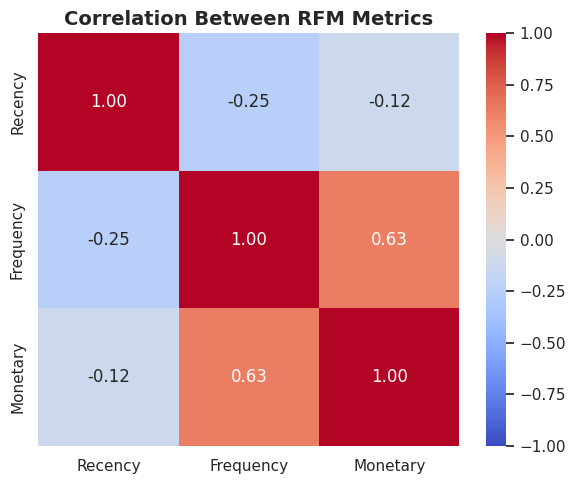

In [12]:
corr = rfm[["Recency", "Frequency", "Monetary"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Between RFM Metrics")
plt.tight_layout()
plt.savefig("../outputs/figures/rfm_correlation_heatmap.png", dpi=150)
plt.show()


## 7. Key Observations

- **Best sellers:** a small set of low-priced, high-volume items (e.g. gift/decor
  products) dominate quantity sold, while the revenue leaders are not always the
  same products — some higher-priced items rank highly in revenue despite lower
  unit sales.
- **Sales trend:** monthly revenue shows a clear seasonal build-up toward the
  end of the year (Q4), consistent with typical UK retail holiday demand,
  with a partial final month if the dataset cuts off mid-month.
- **RFM shape:** Recency, Frequency, and Monetary are all right-skewed — most
  customers order infrequently and recently, while a small group of frequent,
  high-spending customers pulls the distribution's tail out. This confirms why
  Feature Engineering applied a log transform before scaling: it makes the
  distributions closer to symmetric, which K-Means and Hierarchical Clustering
  both need to perform well.
- **Correlation:** Frequency and Monetary are positively correlated (customers
  who order more often also tend to spend more overall), while Recency is
  negatively correlated with both — customers who purchased more recently tend
  to also be more frequent, higher-value customers.

These patterns support using RFM as the feature basis for the clustering models
in Sub-Team B.


## 8. Save the final RFM dataset for Sub-Team B

In [13]:
final_path = "../outputs/customer_rfm_data.csv"
rfm.to_csv(final_path, index=False)
print("Saved:", final_path)
print("Shape:", rfm.shape)


Saved: ../outputs/customer_rfm_data.csv
Shape: (4265, 10)
